In [3]:
import os
import re
import sys
import pickle

sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from src.evaluation.metrics import tune_tfidf_params, tune_hybrid_weights
from src.recommender.hybrid import SVDHybridRecommender
from src.utils.preprocessing import (
    load_clean_data,
    preprocess_content_text,
    get_users_for_eval
)
from src.utils.mappings import get_toeic_part_mapping, get_subject_categories

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="viridis")

In [4]:
# Load data
lectures_df, merged_df = load_clean_data()
print(f"Lectures: {len(lectures_df)}, Interactions: {len(merged_df)}")

Loading from paths:
Lectures: c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\data\cleaned\cleaned_lectures.csv
Merged: c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\data\cleaned\merged_cleaned_data.csv
Successfully loaded 1021 lectures and 117167 interactions
Lectures: 1021, Interactions: 117167


In [5]:
# Prepare bundle features (from notebooks/02_tf_idf.ipynb)
bundle_info = merged_df.groupby('bundle_id').agg({
    'part': 'first',
    'tags': lambda x: ';'.join(set(str(i) for i in x if pd.notna(i))),
    'question_id': lambda x: len(set(x))
}).reset_index()
bundle_info.columns = ['bundle_id', 'part', 'tags', 'question_count']
part_names = get_toeic_part_mapping()
bundle_info['part_name'] = bundle_info['part'].map(part_names)
bundle_info['subject_category'] = bundle_info['tags'].apply(lambda x: get_subject_categories(x)[0] if get_subject_categories(x) else "General")
bundle_info['content_text'] = (
    bundle_info['part_name'].fillna('') + ' ' +
    bundle_info['subject_category'].fillna('') + ' ' +
    bundle_info['tags'].fillna('')
)
bundle_info['content_text'] = bundle_info['content_text'].apply(preprocess_content_text)
bundle_info['content_text'].head()

0    part 1: listening - photographs general 1 2 17...
1    part 1: listening - photographs grammar_basic ...
2    part 1: listening - photographs grammar_basic ...
3    part 2: listening - question-response grammar_...
4    part 2: listening - question-response grammar_...
Name: content_text, dtype: object

In [6]:
# Enhanced TF-IDF tuning
tfidf_params_grid = [
    {'max_features': 3000, 'stop_words': 'english', 'ngram_range': (1, 1), 'min_df': 0.01, 'max_df': 0.95},
    {'max_features': 5000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.01, 'max_df': 0.95},
    {'max_features': 7000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.005, 'max_df': 0.90},
    {'max_features': 10000, 'stop_words': 'english', 'ngram_range': (1, 3), 'min_df': 0.005, 'max_df': 0.85}
]

def build_recommend_fn(tfidf_matrix, vectorizer, min_similarity=0.1):
    sim = cosine_similarity(tfidf_matrix)
    indices = pd.Series(bundle_info.index, index=bundle_info['bundle_id'])
    def recommend_fn(user_id, k=10):
        try:
            user_history = merged_df[merged_df['user_id'] == user_id]
            seen_bundles = set(user_history['bundle_id'].unique())
            rec_scores = {}
            for b in seen_bundles:
                if b not in indices:
                    continue
                idx = indices[b]
                for i, score in enumerate(sim[idx]):
                    b_id = bundle_info.iloc[i]['bundle_id']
                    if b_id not in seen_bundles and score >= min_similarity:
                        rec_scores[b_id] = rec_scores.get(b_id, 0) + score
            if not rec_scores:
                return []
            max_score = max(rec_scores.values())
            rec_scores = {k: v/max_score for k, v in rec_scores.items()}
            top_bundles = sorted(rec_scores.items(), key=lambda x: x[1], reverse=True)[:k]
            return top_bundles  # Return list of (bundle_id, score) tuples
        except Exception as e:
            print(f"Error in recommend_fn for user {user_id}: {str(e)}")
            return []
    return recommend_fn

Testing TF-IDF params: {'max_features': 3000, 'stop_words': 'english', 'ngram_range': (1, 1), 'min_df': 0.01, 'max_df': 0.95}
{'params': "{'max_features': 3000, 'stop_words': 'english', 'ngram_range': (1, 1), 'min_df': 0.01, 'max_df': 0.95}", 'precision': np.float64(0.0), 'recall': np.float64(0.0)}
Testing TF-IDF params: {'max_features': 5000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.01, 'max_df': 0.95}
{'params': "{'max_features': 5000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.01, 'max_df': 0.95}", 'precision': np.float64(0.0), 'recall': np.float64(0.0)}
Testing TF-IDF params: {'max_features': 7000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.005, 'max_df': 0.9}
{'params': "{'max_features': 7000, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 0.005, 'max_df': 0.9}", 'precision': np.float64(0.0), 'recall': np.float64(0.0)}
Testing TF-IDF params: {'max_features': 10000, 'stop_words': 'english', 'ngram_range': (1, 3), 'min_

c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\src\evaluation\metrics.py:103: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


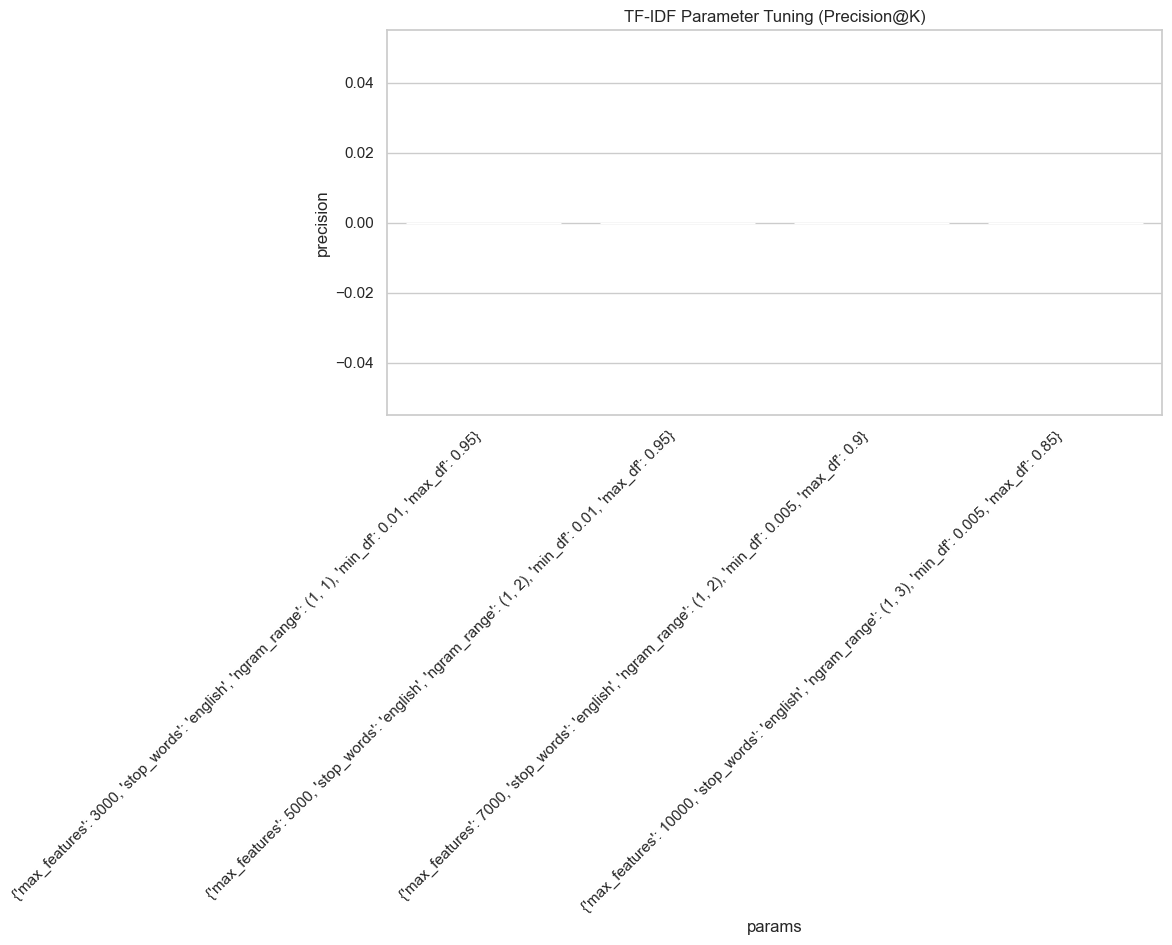

In [7]:
def get_relevant_fn(user_id):
    return merged_df[merged_df['user_id'] == user_id]['bundle_id'].unique().tolist()

tfidf_results = tune_tfidf_params(
    param_grid=tfidf_params_grid,
    vectorizer_class=TfidfVectorizer,
    X_raw=bundle_info['content_text'],
    y_true_fn=lambda: get_users_for_eval(merged_df),
    recommend_fn_builder=build_recommend_fn,
    ground_truth_fn=get_relevant_fn,
    k=10,
    output_path="../data/cleaned/tfidf_tuning_results_updated.csv"
)

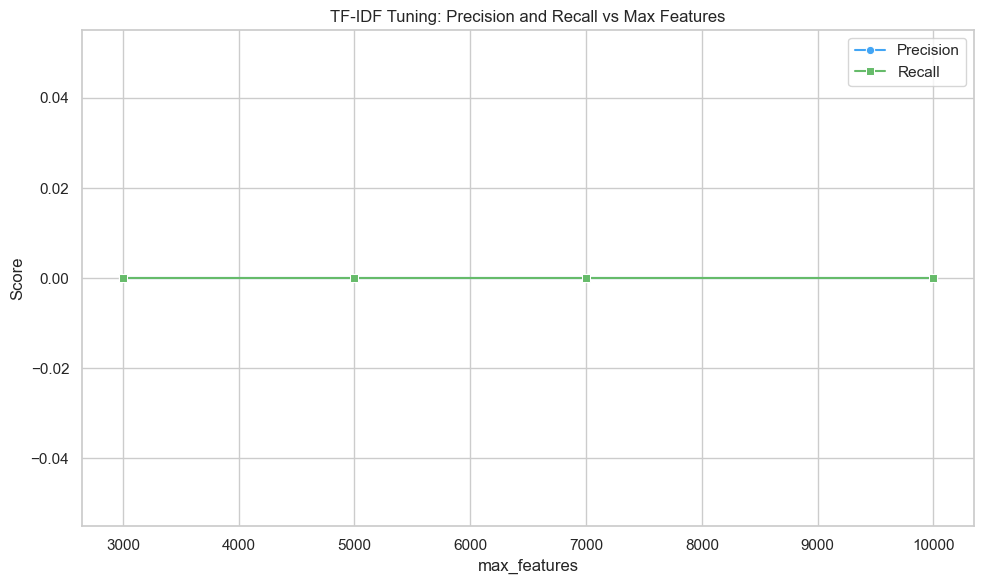

In [ ]:
# Step 1: Load the data
df = pd.read_csv('../data/cleaned/tfidf_tuning_results_updated.csv')

# Step 2: Parse the 'params' column safely and extract useful values
df['params_dict'] = df['params'].apply(lambda x: ast.literal_eval(x))
df['max_features'] = df['params_dict'].apply(lambda d: d.get('max_features'))
df['ngram_range'] = df['params_dict'].apply(lambda d: str(d.get('ngram_range')))

# Step 3: Plot Precision and Recall vs Max Features
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='max_features', y='precision', marker='o', label='Precision', color='#42a5f5')
sns.lineplot(data=df, x='max_features', y='recall', marker='s', label='Recall', color='#66bb6a')

plt.title('TF-IDF Tuning: Precision and Recall vs Max Features')
plt.xlabel('max_features')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
